In [8]:
import numpy as np
import scipy.io
from sklearn import metrics
import pandas as pd
import os
import scipy.io as sio
import os.path
import time
import random
import math
# os.environ['THEANO_FLAGS'] = "device=cuda0,force_device=True,floatX=float32"
# from aesara_theano_fallback import aesara as theano
#import theano

# print(theano.config.device)
# import sys, getopt
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

from keras.layers import Embedding
from keras.models import Model
from keras.layers import Dense, Dropout, Activation, Flatten, Layer, merge, Input, Concatenate, Reshape
from keras.layers.convolutional import Conv1D, MaxPooling1D
from keras.layers.pooling import GlobalMaxPooling1D
from keras.layers.recurrent import LSTM
from keras.layers.wrappers import Bidirectional, TimeDistributed
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import backend as K
import tensorflow.keras as keras
import tensorflow as tf
import matplotlib.pyplot as plt

In [9]:

def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

def readInputAsString(fileName):
    with open(fileName, 'r') as myfile:
        data=myfile.read().replace('\n', ' ')
        # print 
    return data

def reverse_complement(seq):    
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    reverse_complement = ''.join(complement.get(base, base) for base in reversed(seq))
    return reverse_complement

def oneHotEncode(seq):
    import numpy as np
    seq2=list()
    mapping = {"A":[1., 0., 0., 0.], "C": [0., 1., 0., 0.], "G": [0., 0., 1., 0.], "T":[0., 0., 0., 1.]};
    for i in seq:
    	seq2.append(mapping[i]  if i in mapping.keys() else [0., 0., 0., 0.]);
    return seq2;

def ReverseOneHotEncode(arr):
    seq = ''
    nuc_map = ['A', 'C', 'G', 'T']
    for subarr in arr:
        nuc = nuc_map[np.argmax(subarr)]
        seq+=nuc
    return seq;

def writeSeqToFile(d,ones,zeros):
    fname = '/Users/yibeijia/Downloads/nucleosome_occupancy/data/SeqsForFeature.txt'
    out = 'Enriched:\n'
    for i in ones:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(1) + ' ' + seq + '\n'
    out += 'Depleted:\n'
    for i in zeros:
        seq = ReverseOneHotEncode(d[i])
        out = out + str(0) + ' ' + seq + '\n'
    with open(fname, 'w+') as f:
        f.write(out)

In [11]:
###################### Validation Loss Correlation ######################
good_model=[] 
bad_model=[]
Models = []
for model_id in range(1, 11):
    proj_folder ="/home/yibei/Projects/nucleosome_occupancy/tbinet_stuff/train_dense10_kernel10_run"
    data_folder = proj_folder+str(model_id)+"/"
    out_file = proj_folder+str(model_id)+".out"
    out = readInputAsArray(out_file)
    accuracy = []
    start = 0
    print(f"model_id: {model_id}")
    for line in out:
        if start == 2:
            
            l = line.split(",")
            w = l[len(l)-1]
            last_score = float(w[1:len(w)-1])
            print(last_score)
            if last_score > 0.2: #80% validate loss is minimum
                bad_model.append(model_id-1)
                print("bad")
            else:
                good_model.append(model_id-1)
                print("good")
            start = 0
            
        if start == 1:
            start +=1
            
        if 'early stopping' in line:
            start = 1

    model = load_model(data_folder+"tbinet.h5")
    Models.append(model)

#     model.summary()

model_id: 1
0.6881093382835388
bad


2022-02-25 12:39:10.981578: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-25 12:39:10.985578: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-25 12:39:10.985728: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-02-25 12:39:10.986042: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

model_id: 2
0.0763043686747551
good
model_id: 3
0.07626692950725555
good
model_id: 4
0.07694210112094879
good
model_id: 5
0.08371224254369736
good
model_id: 6
0.07118465006351471
good
model_id: 7
0.6881231665611267
bad
model_id: 8
0.07848616689443588
good
model_id: 9
0.08218655735254288
good
model_id: 10
0.06921964138746262
good


In [12]:
bad_model


[0, 6]

In [13]:
def tokenize(str):
    out = []
    for i in range(len(str)-4):
        out.append(str[i:i+5])
    return out
# Normalize an array 
def min_max_norm(arr):
    new_arr = []
    min_v = min(arr)
    max_v = max(arr)
    for num in arr:
        new_arr=new_arr+[(num-min_v)/(max_v-min_v)]
    return(new_arr)

class CharVal(object):
    def __init__(self, char, val):
        self.char = char
        self.val = val

    def __str__(self):
        return self.char

def rgb_to_hex(rgb):
    return '#%02x%02x%02x' % rgb

def color_charvals(s):
    r = 255-int(s.val*255)
#     r = int(s.val*255)
#     print(r)
    color = rgb_to_hex((r, r, 255))
    return 'background-color: %s' % color

# a list of 5mers, token and a list of their attention values, currseq_attention_output
def plot_attention_from_seq(token, currseq_attention_output):

    vals_normalized = min_max_norm(currseq_attention_output)
#     print(vals_normalized)
    # match each 5mer with sum of the 320 dim array attention weight array
    char_vals = [CharVal(c, v) for c, v in zip(token, vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df


def plot_attention_from_map(map):

    # match each 5mer with sum of the 320 dim array attention weight array
    vals_normalized = min_max_norm(map.values())
    char_vals = [CharVal(c, v) for c, v in zip(map.keys(), vals_normalized)]
    char_df = pd.DataFrame(char_vals).transpose()
    # apply coloring values
    char_df = char_df.style.applymap(color_charvals)
    return char_df


# TODO: plot 5mer attention scores together with a mean and variance
# are attention score similar in good models?
## 3. Plot model consistency for attention scores

In [14]:
def read_SD_table(fileName):
    tb_data = readInputAsArray(fileName)
    tb = {}
    DNAshape = tb_data[0].split("\t")
    # print(DNAshape)
    for i in range(1, len(tb_data)):
        line = tb_data[i].split("\t")
        key = line[0]
        value = line[1:]
        for j in range(0, len(value)):
            value[j] = float(value[j])
        tb[key] = value
    # print(tb)
    return(tb)

In [15]:
AllDNAshape = ['Shear', 'Stretch', 'Stagger', 'Buckle', 'Propel', 'Opening', 
'Shift_-1', 'Shift_1', 'Slide_-1', 'Slide_1', 'Rise_-1', 'Rise_1',
            'Tilt_-1', 'Tilt_1', 
'Roll_-1', 'Roll_1', 'Twist_-1', 'Twist_1', 'mingw', 'mingd', 'majgw', 'majgd', 
'Shear-SD', 'Stretch-SD', 'Stagger-SD', 'Buckle-SD', 'Propel-SD', 'Opening-SD', 
'Shift-SD', 'Slide-SD', 'Rise-SD', 'Tilt-SD', 'Roll-SD', 'Twist-SD', 'mingw-SD', 
'mingd-SD', 'majgw-SD', 'majgd-SD']

All_params_names = ["intra_trans","intra_rot","inter_trans","inter_rot","GrooveWidth","intra_trans_SD","inter_trans_SD","intra_rot_SD","inter_rot_SD","GrooveWidth_SD"]

# fileName = "/Users/yibeijia/Downloads/ProjectStuff/mc_pentamer_06042020.txt"
fileName="/home/yibei/Projects/nucleosome_occupancy/mc_pentamer_06042020.txt"
tb = read_SD_table(fileName);

# all_norm_shape_vals, all_shape_vals2 = shape_param_analysis(tb)
# print(len(all_norm_shape_vals))
len(tb.keys())

512

In [29]:
# if you are using batches the outputs will be in batches
# get exact attentions of chars
def analyze_model_attention(d, model_outputs, attention_outputs):
    from IPython.display import display
    
#     model_outputs = attention_wts[0]
#     attention_outputs = attention_wts[1]
    mapped = {}
    reverse_mapped = {}
    ## Lots of sequences seq=1:151
    for seq in range(len(attention_outputs)):
    # for seq in range(1,5):

        # tokens are the 5mers in the current sequence
        tokens = tokenize(ReverseOneHotEncode(d[seq]))
        # for 147bp each sequence, there are 320 feature scores for each bp

        #     for i in range(len(attention_outputs[0])):
        for i in range(len(tokens)):
            token = tokens[i]
            five_mer_attention_output = sum(attention_outputs[seq][i])
            if token in mapped.keys():  # if a 5mer is found
                mapped[token] = mapped[token] + five_mer_attention_output #increase value
            else: #if 5mer not seen yet
                mapped[token] = five_mer_attention_output

    # Plot the mapped dictionary for each 5 mer
    # Darker means higher attention score
    import collections
    # char_df = plot_attention_from_map(mapped)
    # display(char_df)

    ordered_map = collections.OrderedDict(sorted(mapped.items()))
    # d = {'key1': 1, 'key2': 2, 'key3': 3, 'key4': 4, 'key5': 5}
    displayLength= 16
#     print(len(list(ordered_map.items()))/displayLength)
    for i in range(int(len(list(ordered_map.items()))/displayLength)):
    #     print(i)
        display_dict = dict(list(ordered_map.items())[i*displayLength:(i+1)*displayLength])

        char_df = plot_attention_from_map(display_dict)
#         display(char_df)
    return(ordered_map)

def mergeDict(dict1, dict2):
    ''' Merge dictionaries and keep values of common keys in list'''
    
    test_key = list(dict1.keys())[0]
    # if the dict value is already a list, then append to list
    dict3 = {**dict1, **dict2}
    if isinstance(dict1[test_key], list):
        for key, value in dict3.items():
            if key in dict1 and key in dict2:
                dict3[key] = dict1[key]
                dict3[key].append(value)
    else:
        for key, value in dict3.items():
            if key in dict1 and key in dict2:
                dict3[key] = [dict1[key], value]
    return dict3

In [38]:
## Set up a small set of data for predict call
# data_folder = "/Users/yibeijia/Downloads/nucleosome_occupancy/data/train_test_data/"
data_folder ="/home/yibei/Projects/nucleosome_occupancy/data/train_test_data/"
testmat = scipy.io.loadmat(data_folder+'Test_data.mat')

model_idx = 0
AllModelScore = {}

for curr_model in Models[0:11]:
    print(f">>>>>>>>>>> Working on Model: {model_idx}")
    attention_wt_model = tf.keras.models.Model(inputs=curr_model.inputs, outputs=[curr_model.output, curr_model.get_layer('multiply').output])
    batches = 100
    batch_size = round(len(testmat['Test_data'])/batches)
#     print(f"batch_size: {batch_size}; batches: {batches}")

    Attention_outs = []
    Model_outs = []

    for i in range(batches):
#     for i in range(2):
        start = i*batch_size
        end = (i+1)*batch_size
#         print(f"start: {start}; end: {end}")
        d = testmat['Test_data'][start:end]
        labels = testmat['Test_labels']
        new_labels = labels[0][start:end]
        
        # get the index of data that is 0 or 1 
        ones = np.flatnonzero(new_labels == np.max(new_labels))
        zeros = np.flatnonzero(new_labels == np.min(new_labels))

        # # get all model output and attention weights
        attention_wt = attention_wt_model.predict(np.transpose(d,axes=(0,1,2)))
        model_out = attention_wt[0]
        attention_out = attention_wt[1]
        if len(Attention_wts) == 0:
            Model_outs = model_out
            Attention_outs = attention_out
        else:
            Model_outs = np.concatenate((Model_outs, model_out), axis=0)
            Attention_outs = np.concatenate((Attention_outs, attention_out), axis=0)
#     attention_wts = attention_wt_model.predict(np.transpose(d,axes=(0,1,2)))
    ordered_map = analyze_model_attention(d, Model_outs, Attention_outs)
    if (len(AllModelScore.keys()) == 0):
        AllModelScore = ordered_map
    else:
        AllModelScore = mergeDict(AllModelScore, ordered_map)
    model_idx+=1
AllModelScore    

>>>>>>>>>>> Working on Model: 0
>>>>>>>>>>> Working on Model: 1
>>>>>>>>>>> Working on Model: 2
>>>>>>>>>>> Working on Model: 3
>>>>>>>>>>> Working on Model: 4
>>>>>>>>>>> Working on Model: 5
>>>>>>>>>>> Working on Model: 6
>>>>>>>>>>> Working on Model: 7
>>>>>>>>>>> Working on Model: 8
>>>>>>>>>>> Working on Model: 9


{'AAAAA': [2593.8777668888056,
  1105.948166749663,
  1283.1355153193572,
  1082.8963822343835,
  1243.992927526225,
  1066.2555986981577,
  1085.4112843397872,
  1434.808628567599,
  963.9382811692396,
  1192.4883533734228],
 'AAAAC': [274.529223940886,
  133.21363458129207,
  191.65015885736221,
  122.41624341979443,
  214.46331018177133,
  130.1366007383259,
  192.7253804848968,
  260.5258019812993,
  172.7982661897838,
  192.8516071383156],
 'AAAAG': [272.63125795681174,
  202.4959516049231,
  271.37196916949154,
  238.0886087061743,
  253.27806116237974,
  261.5886331114389,
  180.84359178892552,
  291.95212278470933,
  206.8089958759636,
  289.5982272949539],
 'AAAAT': [1174.43410908014,
  528.5467186618539,
  466.56149155510235,
  455.494670269149,
  782.3519632482912,
  618.1787035257398,
  641.0102434449965,
  670.8224355345149,
  500.35734979670633,
  470.3511589463193],
 'AAACA': [494.49078228655725,
  151.5063214409362,
  121.01110463347925,
  116.44617612395662,
  189.0161

<AxesSubplot:xlabel='Observation', ylabel='Value'>

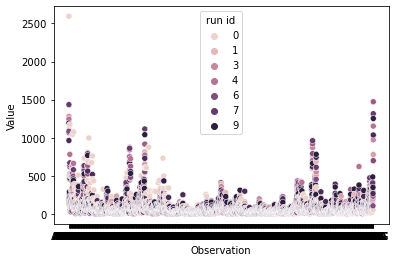

In [39]:
# sns.set_theme(style="darkgrid")

# sns.lmplot(x="five_mer", y="reverse_comp",data=corr);
# plt.title("Attension Score Correlation: \n5-mers vs. Reverse Complements", fontsize=15)
# plt.xlabel("5-mers", fontsize=15);
# plt.ylabel("Reverse complement of 5-mers", fontsize=15);
# seqs = []
# rseqs = []

# Add person correlation annotation
# from scipy import stats
# num = stats.pearsonr(corr['five_mer'], corr['reverse_comp'])[0]**2
# text = "$R^2$ = " + f'{num:.5f}'

# plt.text(80, 110, text, horizontalalignment='left', size='medium', color='black', weight='semibold')
import seaborn as sns
df = pd.DataFrame.from_dict(AllModelScore, orient='index')
df.index.rename('Observation', inplace=True)

stacked = df.stack().reset_index()
stacked.rename(columns={'level_1': 'run id', 0: 'Value'}, inplace=True)

# sns.swarmplot(data=stacked, x='Observation', y='Value', hue='run id')
sns.scatterplot(data=stacked, x='Observation', y='Value', hue='run id')


In [40]:
import seaborn as sns
df = pd.DataFrame.from_dict(AllModelScore, orient='index')
df.index.rename('Observation', inplace=True)

stacked = df.stack().reset_index()
stacked.rename(columns={'level_1': 'run id', 0: 'Value'}, inplace=True)

In [ ]:
stacked

In [41]:
df

,0,1,2,3,4,5,6,7,8,9
Observation,,,,,,,,,,
AAAAA,2593.877767,1105.948167,1283.135515,1082.896382,1243.992928,1066.255599,1085.411284,1434.808629,963.938281,1192.488353
AAAAC,274.529224,133.213635,191.650159,122.416243,214.463310,130.136601,192.725380,260.525802,172.798266,192.851607
AAAAG,272.631258,202.495952,271.371969,238.088609,253.278061,261.588633,180.843592,291.952123,206.808996,289.598227
AAAAT,1174.434109,528.546719,466.561492,455.494670,782.351963,618.178704,641.010243,670.822436,500.357350,470.351159
AAACA,494.490782,151.506321,121.011105,116.446176,189.016193,116.496013,176.442379,136.790647,145.095346,119.961666
...,...,...,...,...,...,...,...,...,...,...
TTTGT,37.487449,195.590970,145.897556,216.611921,220.309559,170.096292,111.120752,242.310410,178.421772,247.081244
TTTTA,183.103345,323.913523,210.759336,303.522556,288.976663,324.028730,238.485822,400.330957,337.977968,321.060904
TTTTC,136.576315,361.311767,218.435837,329.063025,416.452039,248.213557,183.870627,408.065565,247.187436,486.086438


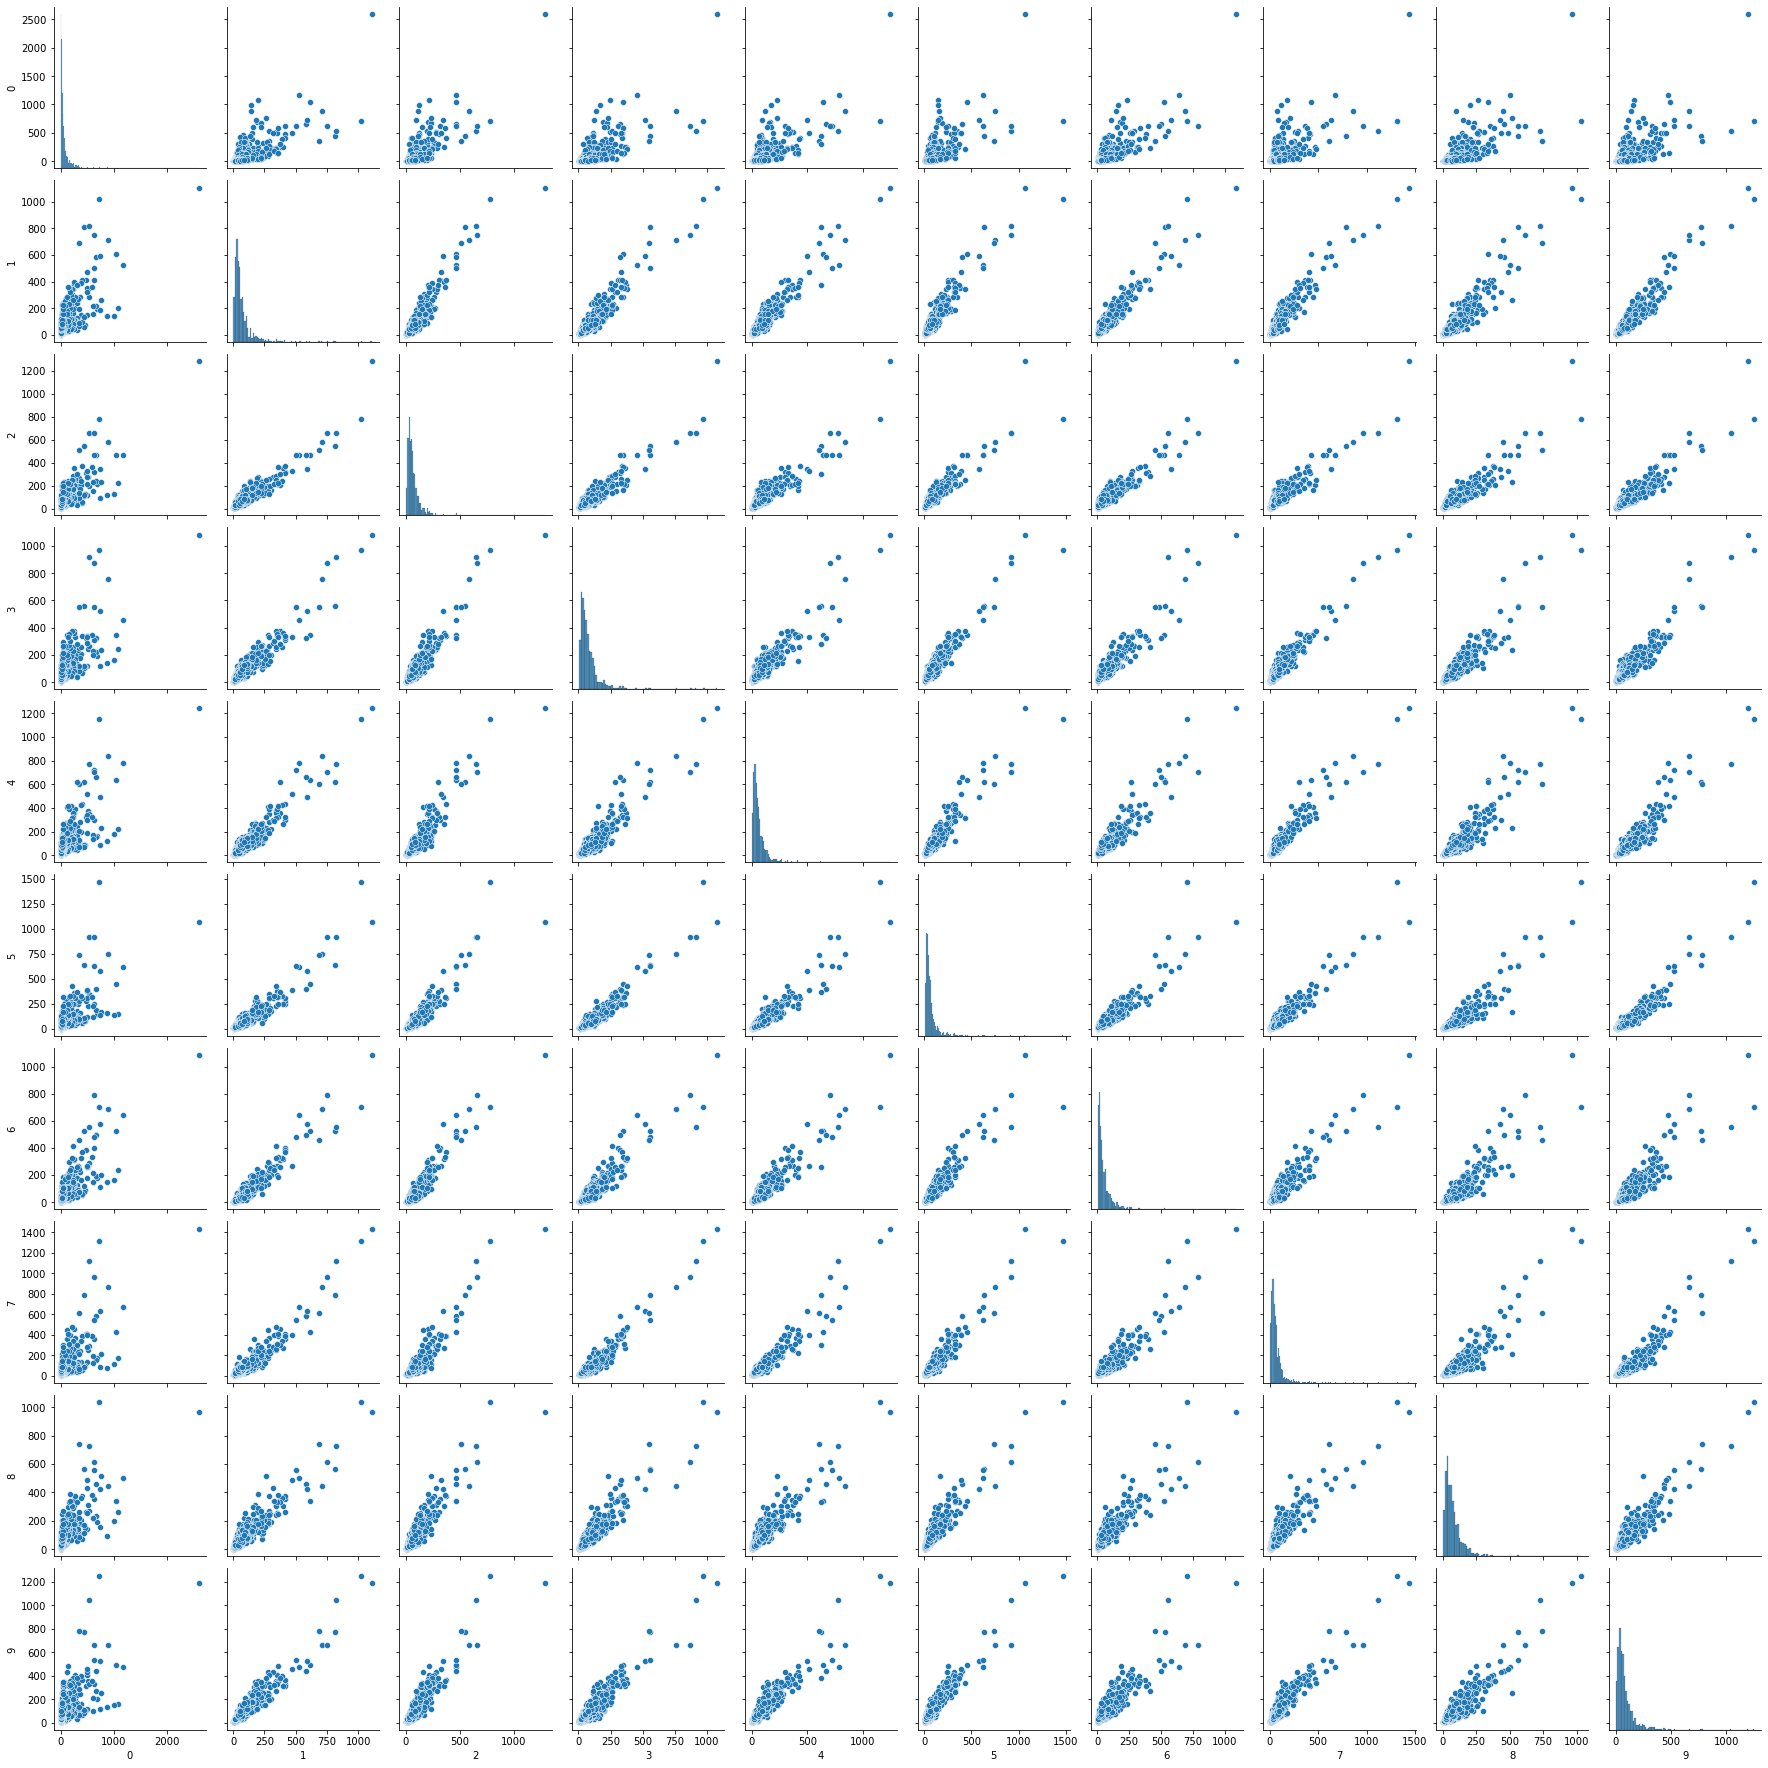

In [42]:
sns.pairplot(df);

In [18]:
from pandas import *
import numpy as np
# from libraries.settings import *
from scipy.stats.stats import pearsonr
import itertools

correlations = {}
columns = df.columns.tolist()

for col_a, col_b in itertools.combinations(columns, 2):
    correlations[str(col_a) + '__' + str(col_b)] = pearsonr(df.loc[:, col_a], df.loc[:, col_b])

result = DataFrame.from_dict(correlations, orient='index')
result.columns = ['PCC', 'p-value']

print(result.sort_index())

           PCC        p-value
0__1  0.675169  3.298703e-137
0__2  0.716311  6.649088e-162
0__3  0.667531  4.641655e-133
0__4  0.691839  1.031480e-146
0__5  0.647933  5.845379e-123
0__6  0.763488  2.811738e-196
0__7  0.642969  1.612476e-120
0__8  0.716049  9.857104e-162
0__9  0.615743  6.713704e-108
1__2  0.918659   0.000000e+00
1__3  0.911348   0.000000e+00
1__4  0.920228   0.000000e+00
1__5  0.919527   0.000000e+00
1__6  0.931001   0.000000e+00
1__7  0.914176   0.000000e+00
1__8  0.912001   0.000000e+00
1__9  0.932160   0.000000e+00
2__3  0.916398   0.000000e+00
2__4  0.906690   0.000000e+00
2__5  0.902614   0.000000e+00
2__6  0.919711   0.000000e+00
2__7  0.898038   0.000000e+00
2__8  0.900652   0.000000e+00
2__9  0.889732   0.000000e+00
3__4  0.893771   0.000000e+00
3__5  0.916876   0.000000e+00
3__6  0.908341   0.000000e+00
3__7  0.921041   0.000000e+00
3__8  0.904172   0.000000e+00
3__9  0.909846   0.000000e+00
4__5  0.920560   0.000000e+00
4__6  0.913474   0.000000e+00
4__7  0.92

In [21]:
bad_model

[0, 6]

In [43]:
good_model

[1, 2, 3, 4, 5, 7, 8, 9]

In [44]:
good_df = df.drop(columns=bad_model, axis=1)

In [45]:
good_df

,1,2,3,4,5,7,8,9
Observation,,,,,,,,
AAAAA,1105.948167,1283.135515,1082.896382,1243.992928,1066.255599,1434.808629,963.938281,1192.488353
AAAAC,133.213635,191.650159,122.416243,214.463310,130.136601,260.525802,172.798266,192.851607
AAAAG,202.495952,271.371969,238.088609,253.278061,261.588633,291.952123,206.808996,289.598227
AAAAT,528.546719,466.561492,455.494670,782.351963,618.178704,670.822436,500.357350,470.351159
AAACA,151.506321,121.011105,116.446176,189.016193,116.496013,136.790647,145.095346,119.961666
...,...,...,...,...,...,...,...,...
TTTGT,195.590970,145.897556,216.611921,220.309559,170.096292,242.310410,178.421772,247.081244
TTTTA,323.913523,210.759336,303.522556,288.976663,324.028730,400.330957,337.977968,321.060904
TTTTC,361.311767,218.435837,329.063025,416.452039,248.213557,408.065565,247.187436,486.086438


In [26]:
bad_df = df.drop(columns=good_model, axis=1)

In [27]:
bad_df

,0,6
Observation,,
AAAAA,234.042485,116.891062
AAAAC,18.704786,14.949398
AAAAG,40.944186,24.558551
AAAAT,175.025275,91.262972
AAACA,28.575165,14.369296
...,...,...
TTTGT,6.358447,14.760878
TTTTA,20.765854,30.840005
TTTTC,16.101939,21.277020


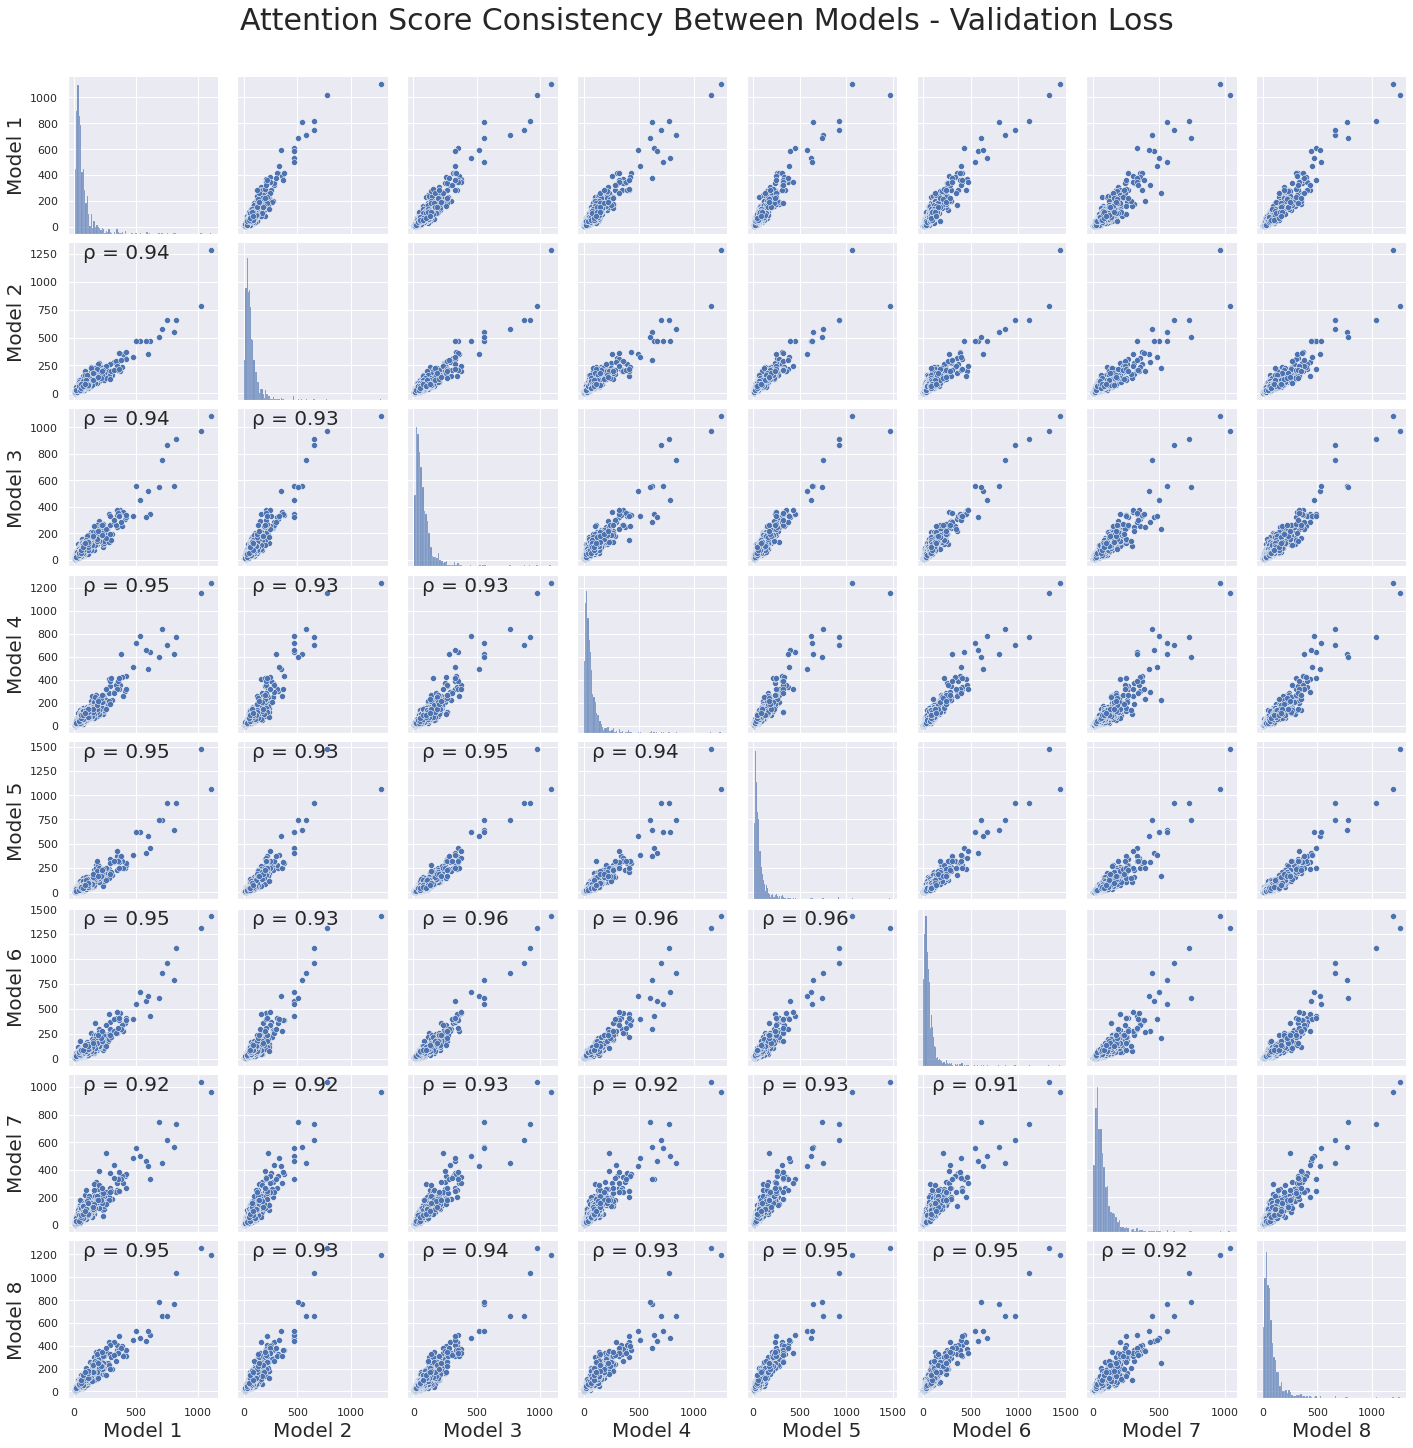

In [61]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt 

def corrfunc(x, y, ax=None, **kws):
    """Plot the correlation coefficient in the top left hand corner of a plot."""
    r, _ = pearsonr(x, y)
    ax = ax or plt.gca()
    ax.annotate(f'ρ = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes, fontsize=20)
sns.set_theme(style="darkgrid")
g=sns.pairplot(good_df);
# g=sns.pairplot(bad_df);
g.map_lower(corrfunc)

xlabels,ylabels = [],[]

# Need to adjust the model to remove bad model indexes
for ax in g.axes[-1,:]:
    model_num = ax.xaxis.get_label_text()
    if model_num == '7':
        model_num = '6'
    elif model_num == '8':
        model_num = '7'
    elif model_num == '9':
        model_num = '8'

    xlabel = "Model "+ model_num
    xlabels.append(xlabel)

for ax in g.axes[:,0]:
    model_num = ax.yaxis.get_label_text()
    if model_num == '7':
        model_num = '6'
    elif model_num == '8':
        model_num = '7'
    elif model_num == '9':
        model_num = '8'
    ylabel = "Model "+ model_num
    ylabels.append(ylabel)

for i in range(len(xlabels)):
    for j in range(len(ylabels)):
        g.axes[len(ylabels)-1,i].xaxis.set_label_text(xlabels[i], fontsize=20)
        g.axes[j,0].yaxis.set_label_text(ylabels[j], fontsize=20)
g.fig.suptitle("Attention Score Consistency Between Models - Validation Loss", y=1.01, fontsize=30) # y= some height>1
g.tight_layout()
fig_path='/home/yibei/Projects/nucleosome_occupancy/figs/'
plt.savefig( fig_path + 'modelConsistency.png', dpi=200, bbox_inches='tight')
# plt.show()

In [66]:
sns.lmplot(x=list(range(512)), y=good_df(columns=[1]);

SyntaxError: invalid syntax (<ipython-input-66-5949ac4e1367>, line 1)

In [70]:
test_df = good_df.loc[:,1]

In [71]:
test_df

Observation
AAAAA    108.430359
AAAAC     11.583080
AAAAG     27.260427
AAAAT     72.828532
AAACA     10.248859
            ...    
TTTGT     29.391351
TTTTA     34.570347
TTTTC     35.446812
TTTTG     19.788249
TTTTT    102.718814
Name: 1, Length: 1024, dtype: float64